In [1]:
%pip install reverse_geocoder
%pip install pycountry-convert

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import reverse_geocoder as rg
import pycountry_convert as pc

### Showing the process to merge the two original .csv files

In [3]:
eq_95_23 = pd.read_csv("data/earthquake_1995-2023.csv")
eq_95_23

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,"M 7.1 - 85 km S of Tungor, Russia",7.1,27-05-1995 13:03,0,9,NaN,0,776,us,0,0.000000,0.0,mwb,11.000,52.6290,142.8270,"Tungor, Russia",Asia,Russia
996,"M 7.7 - 249 km E of Vao, New Caledonia",7.7,16-05-1995 20:12,0,4,NaN,0,912,us,0,0.000000,0.0,mw,20.200,-23.0080,169.9000,"Vao, New Caledonia",NaN,NaN
997,"M 6.9 - 27 km NNW of Maubara, Timor Leste",6.9,14-05-1995 11:33,0,6,NaN,0,732,us,0,0.000000,0.0,mw,11.200,-8.3780,125.1270,"Maubara, Timor Leste",NaN,Indonesia
998,"M 6.6 - 10 km W of Aianí, Greece",6.6,13-05-1995 08:47,0,9,NaN,0,670,us,0,0.000000,0.0,mw,14.000,40.1490,21.6950,"Aianí, Greece",Europe,Greece


In [4]:
eq_data = pd.read_csv("data/earthquake_data.csv")
eq_data

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 7.0 - 18 km SW of Malango, Solomon Islands",7.0,22-11-2022 02:03,8,7,green,1,768,us,117,0.509,17.0,mww,14.000,-9.7963,159.596,"Malango, Solomon Islands",Oceania,Solomon Islands
1,"M 6.9 - 204 km SW of Bengkulu, Indonesia",6.9,18-11-2022 13:37,4,4,green,0,735,us,99,2.229,34.0,mww,25.000,-4.9559,100.738,"Bengkulu, Indonesia",NaN,NaN
2,M 7.0 -,7.0,12-11-2022 07:09,3,3,green,1,755,us,147,3.125,18.0,mww,579.000,-20.0508,-178.346,NaN,Oceania,Fiji
3,"M 7.3 - 205 km ESE of Neiafu, Tonga",7.3,11-11-2022 10:48,5,5,green,1,833,us,149,1.865,21.0,mww,37.000,-19.2918,-172.129,"Neiafu, Tonga",NaN,NaN
4,M 6.6 -,6.6,09-11-2022 10:14,0,2,green,1,670,us,131,4.998,27.0,mww,624.464,-25.5948,178.278,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,"M 7.7 - 28 km SSW of Puerto El Triunfo, El Sal...",7.7,13-01-2001 17:33,0,8,NaN,0,912,us,427,0.000,0.0,mwc,60.000,13.0490,-88.660,"Puerto El Triunfo, El Salvador",NaN,NaN
778,"M 6.9 - 47 km S of Old Harbor, Alaska",6.9,10-01-2001 16:02,5,7,NaN,0,745,ak,0,0.000,0.0,mw,36.400,56.7744,-153.281,"Old Harbor, Alaska",North America,NaN
779,"M 7.1 - 16 km NE of Port-Olry, Vanuatu",7.1,09-01-2001 16:49,0,7,NaN,0,776,us,372,0.000,0.0,mwb,103.000,-14.9280,167.170,"Port-Olry, Vanuatu",NaN,Vanuatu
780,"M 6.8 - Mindanao, Philippines",6.8,01-01-2001 08:54,0,5,NaN,0,711,us,64,0.000,0.0,mwc,33.000,6.6310,126.899,"Mindanao, Philippines",NaN,NaN


In [5]:
eq_all = pd.merge(eq_95_23, eq_data, how='outer')
eq_all

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 10 km NE of San Simeon, California",6.5,22-12-2003 19:15,7,9,NaN,0,1390,nc,65,0.04685,71.0,mw,8.382,35.7005,-121.101,"San Simeon, California",North America,United States of America
1,"M 6.5 - 10 km SW of Juradó, Colombia",6.5,08-11-2000 06:59,0,7,NaN,0,650,us,462,0.00000,0.0,mwc,17.000,7.0420,-77.829,"Juradó, Colombia",NaN,Colombia
2,"M 6.5 - 105 km ESE of Kokopo, Papua New Guinea",6.5,28-07-2012 20:03,5,6,NaN,0,653,us,576,0.00000,11.7,mww,41.000,-4.6510,153.173,"Kokopo, Papua New Guinea",NaN,Papua New Guinea
3,"M 6.5 - 106 km SW of Padang, Indonesia",6.5,10-04-2005 11:14,3,6,NaN,0,657,us,478,0.00000,21.2,mwc,30.000,-1.7140,99.779,"Padang, Indonesia",NaN,Indonesia
4,"M 6.5 - 107 km NE of Calama, Chile",6.5,28-03-2002 04:56,0,5,NaN,0,650,us,486,0.00000,0.0,mwc,125.100,-21.6630,-68.329,"Calama, Chile",South America,Chile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,"M 8.6 - 78 km WSW of Singkil, Indonesia",8.6,28-03-2005 16:09,0,8,NaN,0,1138,official,510,0.00000,22.1,mww,30.000,2.0850,97.108,"Singkil, Indonesia",NaN,Indonesia
996,M 8.6 - off the west coast of northern Sumatra,8.6,11-04-2012 08:38,9,7,yellow,0,2048,official,499,0.00000,16.6,mw,20.000,2.3270,93.063,off the west coast of northern Sumatra,NaN,NaN
997,"M 8.8 - 36 km WNW of Quirihue, Chile",8.8,27-02-2010 06:34,8,8,NaN,0,1991,official,454,0.00000,17.8,mww,22.900,-36.1220,-72.898,"Quirihue, Chile",South America,Chile
998,M 9.1 - 2004 Sumatra - Andaman Islands Earthquake,9.1,26-12-2004 00:58,0,8,NaN,0,1274,official,601,0.00000,22.0,mw,30.000,3.2950,95.982,2004 Sumatra - Andaman Islands Earthquake,NaN,Indonesia


### Reading in the group's merged data


In [6]:
eq_all = pd.read_csv('data/merged_earthquake_data.csv')
eq_all['date_time'] = pd.to_datetime(eq_all['date_time'], dayfirst=False)
eq_all

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,VU
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,SV
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,AR
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,US
4,M 7.3 - Alaska Peninsula,7.3,2023-07-16 06:48:00,0,5,orange,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,US
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1777,"M 7.7 - 28 km SSW of Puerto El Triunfo, El Sal...",7.7,2001-01-13 17:33:00,0,8,orange,0,912,us,427,0.000000,0.0,mwc,60.000,13.0490,-88.6600,"Puerto El Triunfo, El Salvador",NaN,SV
1778,"M 6.9 - 47 km S of Old Harbor, Alaska",6.9,2001-01-10 16:02:00,5,7,green,0,745,ak,0,0.000000,0.0,mw,36.400,56.7744,-153.2810,"Old Harbor, Alaska",North America,US
1779,"M 7.1 - 16 km NE of Port-Olry, Vanuatu",7.1,2001-01-09 16:49:00,0,7,green,0,776,us,372,0.000000,0.0,mwb,103.000,-14.9280,167.1700,"Port-Olry, Vanuatu",NaN,VU
1780,"M 6.8 - Mindanao, Philippines",6.8,2001-01-01 08:54:00,0,5,green,0,711,us,64,0.000000,0.0,mwc,33.000,6.6310,126.8990,"Mindanao, Philippines",NaN,PH


## EDA: Latitude Histogram

Text(0.5, 1.0, 'Latitude Histogram')

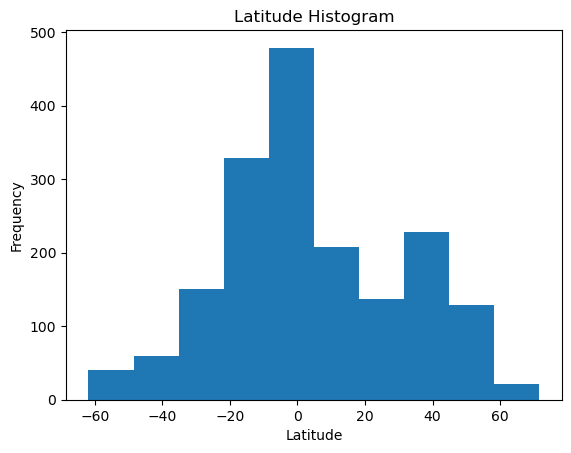

In [7]:
plt.hist(eq_all['latitude'])
plt.xlabel('Latitude')
plt.ylabel('Frequency')
plt.title('Latitude Histogram')


Text(0.5, 1.0, 'Latitude Histogram')

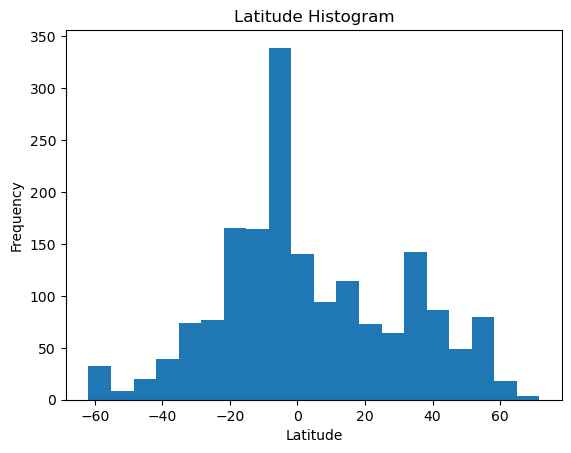

In [8]:
plt.hist(eq_all['latitude'], bins=20)
plt.xlabel('Latitude')
plt.ylabel('Frequency')
plt.title('Latitude Histogram')

Text(0.5, 1.0, 'Latitude Histogram')

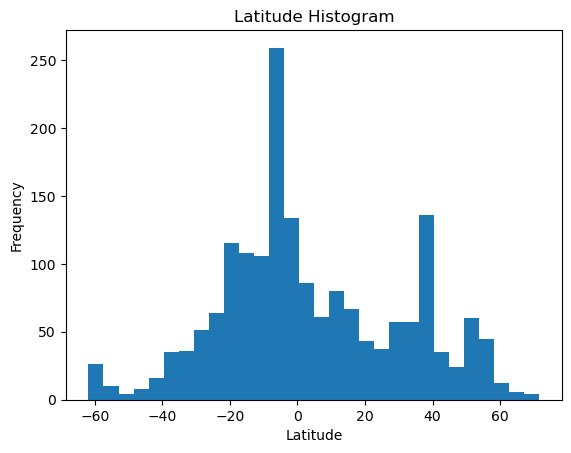

In [9]:
plt.hist(eq_all['latitude'], bins=30)
plt.xlabel('Latitude')
plt.ylabel('Frequency')
plt.title('Latitude Histogram')

## Data Cleaning and Transformation: Countries from Lat/Long

In [10]:
coords = list(zip(eq_all['latitude'], eq_all['longitude']))

if coords:
    results = rg.search(coords)

    eq_all['country'] = [res['cc'] for res in results]

# Saving results to existing .csv
eq_all.to_csv('data/merged_earthquake_data.csv', index=False)

# Viewing results
eq_all.head()

Loading formatted geocoded file...


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,2023-08-16 12:47:00,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,VU
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,2023-07-19 00:22:00,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,SV
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,2023-07-17 03:05:00,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,AR
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,2023-07-16 06:48:00,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,US
4,M 7.3 - Alaska Peninsula,7.3,2023-07-16 06:48:00,0,5,orange,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,US


## Continents from Country Codes

In [ ]:
continent_mapping = {
    'AF': 'Africa',
    'AS': 'Asia',
    'EU': 'Europe',
    'NA': 'North America',
    'OC': 'Oceanea',
    'SA': 'South America',
    'AN': 'Antarctica'
}

def get_continent(country_code):
    try:
        continent_code = pc.country_alpha2_to_continent_code(country_code)
        return continent_mapping.get(continent_code)
    except:
        return None
    
eq_all['continent'] = eq_all['country'].apply(get_continent)
# Timor Leste got missed, filling its 9 entries with Asia
eq_all['continent'] = eq_all['continent'].fillna('Asia')
eq_all[['country', 'continent']].head()

# Saving results to existing .csv
eq_all.to_csv('data/merged_earthquake_data.csv', index=False)

## Visualizing Continent and Sig

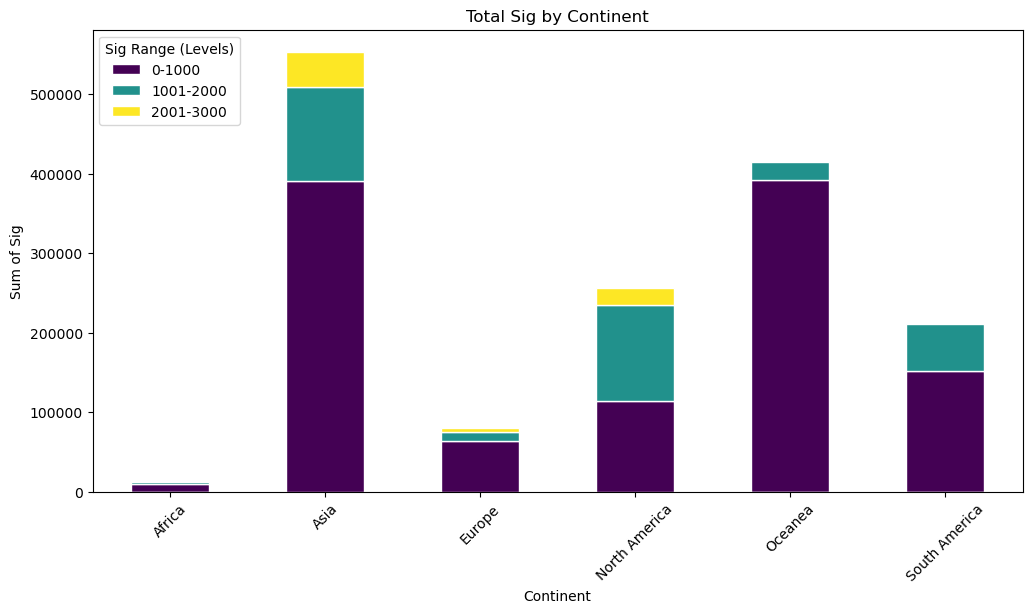

In [ ]:
bins = [0, 1000, 2000, 3000]
labels = ['0-1000', '1001-2000', '2001-3000']

eq_all['sig_range'] = pd.cut(eq_all['sig'], bins=bins, labels=labels)

pivot_sig = eq_all.groupby(['continent', 'sig_range'], observed=False)['sig'].sum().unstack(fill_value=0)

ax = pivot_sig.plot(kind='bar',
                    stacked=True,
                    figsize=(12, 6),
                    colormap='viridis',
                    edgecolor='white')

plt.title('Total Sig by Continent')
plt.xlabel('Continent')
plt.ylabel('Sum of Sig')
plt.xticks(rotation=45)
plt.legend(title='Sig Range (Levels)', loc='upper left')

plt.tight_layout
plt.show()